In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv("dataset/StudentsPerformance.csv")

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [10]:
df.shape

(1000, 8)

In [11]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [12]:
df.duplicated().sum()

np.int64(0)

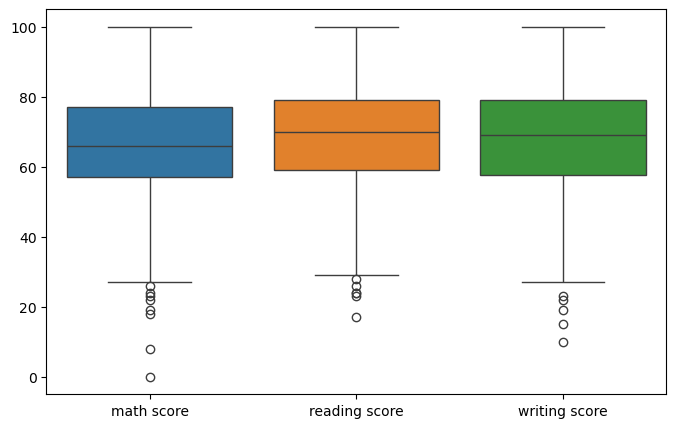

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['math score','reading score','writing score']])
plt.show()

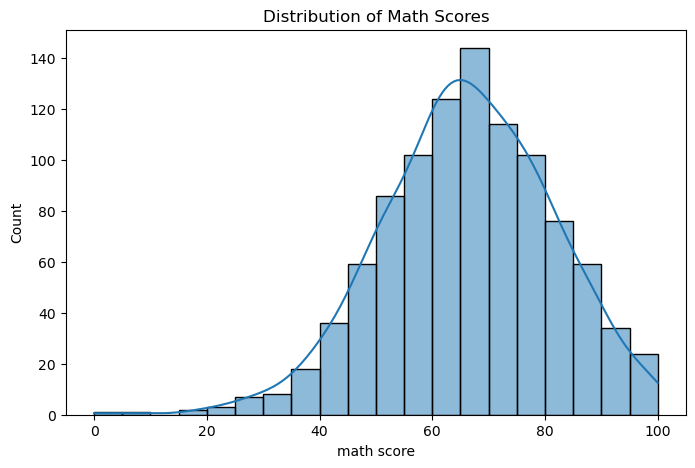

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df['math score'], bins=20, kde=True)

plt.title("Distribution of Math Scores")

plt.show()

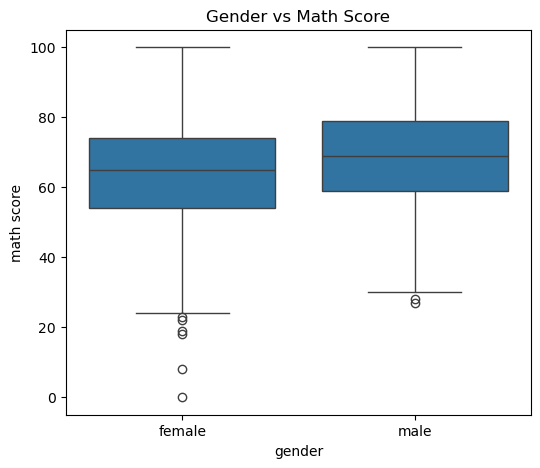

In [16]:
plt.figure(figsize=(6,5))

sns.boxplot(x='gender', y='math score', data=df)

plt.title("Gender vs Math Score")

plt.show()

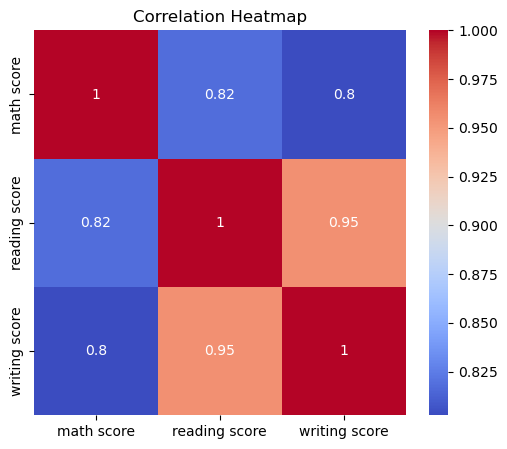

In [17]:
plt.figure(figsize=(6,5))

sns.heatmap(
    df[['math score','reading score','writing score']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [18]:
df['pass_fail'] = df['math score'].apply(
    lambda x: 1 if x >= 40 else 0
)

In [21]:
df[['math score', 'pass_fail']].head(10)

,math score,pass_fail
0,72,1
1,69,1
2,90,1
3,47,1
4,76,1
5,71,1
6,88,1
7,40,1
8,64,1
9,38,0


In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [23]:
categorical_cols = df.select_dtypes(include='object').columns

print(categorical_cols)

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='object')


In [24]:
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [25]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,pass_fail
0,0,1,1,1,1,72,72,74,1
1,0,2,4,1,0,69,90,88,1
2,0,1,3,1,1,90,95,93,1
3,1,0,0,0,1,47,57,44,1
4,1,2,4,1,1,76,78,75,1


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [27]:
numerical_cols = ['reading score' , 'writing score']
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X = df.drop(['math score','pass_fail'],axis=1)
y = df['math score']

In [30]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [31]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 7)
(200, 7)
(800,)
(200,)


In [53]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

In [42]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [47]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test,y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 6.445
MSE: 73.755
RMSE: 8.588073124979783
R2 Score: 0.6969035713228985


In [54]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.08


In [55]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


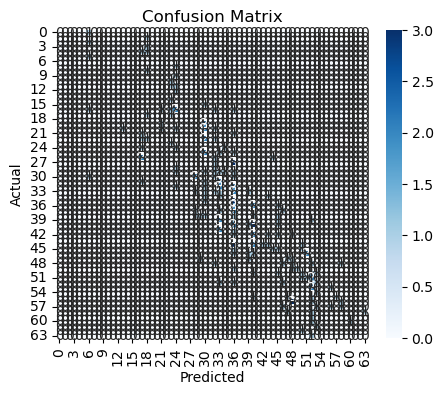

In [56]:
plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [57]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [58]:
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.05


In [59]:
cm_dt = confusion_matrix(y_test, dt_pred)

print(cm_dt)

[[0 0 1 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


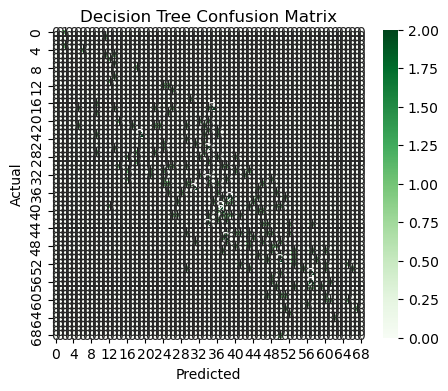

In [61]:
plt.figure(figsize=(5,4))

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Decision Tree Confusion Matrix")

plt.show()

for classification 

In [67]:
# X_cls = df.drop(['pass_fail'], axis=1)

# y_cls = df['pass_fail']
X_cls = df.drop(['math score', 'pass_fail'], axis=1)

y_cls = df['pass_fail']

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42
)

In [69]:
print(y_train.unique())

[1 0]


In [70]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

In [71]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", accuracy)

Logistic Regression Accuracy: 0.985


In [72]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [73]:
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.96


In [74]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.975


In [76]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.73      0.84        11
           1       0.98      1.00      0.99       189

    accuracy                           0.98       200
   macro avg       0.99      0.86      0.92       200
weighted avg       0.99      0.98      0.98       200



In [78]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.64      0.64      0.64        11
           1       0.98      0.98      0.98       189

    accuracy                           0.96       200
   macro avg       0.81      0.81      0.81       200
weighted avg       0.96      0.96      0.96       200



In [79]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.88      0.64      0.74        11
           1       0.98      0.99      0.99       189

    accuracy                           0.97       200
   macro avg       0.93      0.82      0.86       200
weighted avg       0.97      0.97      0.97       200



In [80]:
import pickle

pickle.dump(log_model, open("student_model.pkl", "wb"))